# Why Early Change-Order Features Did Not Improve The 50% Delay Model

This diagnostic notebook investigates why adding change-order information available by the planned 50% project date reduced or failed to improve model performance.

It does **not** refit the full modeling workflow. Instead, it reads the already generated 50% model outputs and the audit feature table, then checks:

- early change-order coverage and sparsity;
- target distribution by early change-order presence;
- train/test distribution drift;
- whether early change-order features are predictive by themselves;
- feature importance and whether CO features are actually used;
- whether the CO feature signal is concentrated in a small subset of projects;
- whether regularization likely suppresses sparse CO features in favor of stronger baseline setup features.

## Clear Findings From This Diagnostic Review

This section states the main findings directly before the detailed diagnostic tables and charts.

1. **Early change-order data is sparse at the project level.** Only a small minority of modeled projects have approved change orders by the planned midpoint. Early time change orders are especially sparse.

2. **The change-order features are weak predictors by themselves.** Cross-validated balanced accuracy for change-order-only models is low: time CO only is about `0.358`, budget CO only is about `0.392`, and all CO features together are about `0.397`. These values are only modestly above random behavior for a three-class task.

3. **Adding early change-order features does not consistently improve the global three-bin model.** The baseline beginning-only model remains strongest or near-strongest. Budget CO features give a small balanced-accuracy lift on the random hash split, but that lift does not persist on the time split.

4. **The signal drifts over time.** Early budget CO coverage rises from about `13.0%` in the older training projects to about `20.3%` in the newer test projects. Early time CO coverage rises from about `2.1%` to about `4.3%`. That shift makes time-based generalization harder.

5. **Projects with early COs are a distinct subgroup, but not a clean final-delay class.** In the time test set, projects with any early CO end up roughly `39.3%` on time, `12.4%` mildly late, and `48.3%` moderately/severely late. That is risk-relevant, but not enough to cleanly sort all projects into the three final delay bins.

6. **Regularized random forests naturally favor broader setup features.** The tuned models use conservative leaf sizes, so sparse CO features must provide strong, repeatable split value to survive. In this data, broader beginning-of-project setup features are more stable.

Overall: **early approved change orders appear to be useful context for a subset of projects, but they are not yet strong enough as direct add-on features to improve the global three-bin delay classifier.** A better next modeling approach is likely a two-stage design: baseline project risk first, then a CO-specific risk adjustment for projects that actually have early approved CO activity.


In [1]:
from pathlib import Path
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score, f1_score, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 180)
pd.set_option('display.width', 220)

MODEL_FEATURE_PATH = Path('project_delay_50pct_co_project_features_2026-06-14.csv')
RESULTS_PATH = Path('project_delay_50pct_co_model_results_2026-06-14.csv')
LIFT_PATH = Path('project_delay_50pct_co_lift_vs_baseline_2026-06-14.csv')
REG_PATH = Path('project_delay_50pct_co_regularization_params_2026-06-14.csv')
HASH_IMPORTANCE_PATH = Path('project_delay_50pct_co_combined_importances_hash_80_20_2026-06-14.csv')
TIME_IMPORTANCE_PATH = Path('project_delay_50pct_co_combined_importances_time_old_80_new_20_2026-06-14.csv')

RANDOM_STATE = 42

## Load Diagnostic Inputs

In [2]:
df = pd.read_csv(MODEL_FEATURE_PATH, low_memory=False)
results = pd.read_csv(RESULTS_PATH)
lift = pd.read_csv(LIFT_PATH)
reg = pd.read_csv(REG_PATH)
hash_imp = pd.read_csv(HASH_IMPORTANCE_PATH)
time_imp = pd.read_csv(TIME_IMPORTANCE_PATH)

for c in ['PLANNEDSTARTDATE', 'PLANNEDENDDATE', 'PROJECTMIDPOINTDATE']:
    df[c] = pd.to_datetime(df[c], errors='coerce')

print(f'Rows in 50% modeling feature audit table: {len(df):,}')
print(f'Columns: {df.shape[1]:,}')
print('\nModel results:')
display(results)
print('\nLift vs baseline:')
display(lift)
print('\nRegularization choices:')
display(reg)

Rows in 50% modeling feature audit table: 3,469
Columns: 39

Model results:


,FeatureSet,Split,TrainRows,TestRows,Accuracy,BalancedAccuracy,MacroF1,WeightedF1,OVR_AUC,max_depth,min_samples_leaf,min_samples_split,max_features
0,baseline_beginning_only,hash_80_20,2743,726,0.863636,0.724106,0.668618,0.883405,0.919630,16.0,20,10,0.15
1,baseline_beginning_only,time_old_80_new_20,2776,693,0.767677,0.566284,0.567637,0.764413,0.837073,16.0,20,10,0.15
2,baseline_plus_time_co_by_50pct,hash_80_20,2743,726,0.841598,0.675814,0.637044,0.866379,0.905925,NaN,20,10,sqrt
3,baseline_plus_time_co_by_50pct,time_old_80_new_20,2776,693,0.746032,0.544701,0.547883,0.747756,0.817932,NaN,20,10,sqrt
4,baseline_plus_budget_co_by_50pct,hash_80_20,2743,726,0.834711,0.737368,0.653204,0.867367,0.907010,8.0,20,10,sqrt
5,baseline_plus_budget_co_by_50pct,time_old_80_new_20,2776,693,0.734488,0.557856,0.558639,0.744648,0.821942,8.0,20,10,sqrt
6,baseline_plus_time_and_budget_co_by_50pct,hash_80_20,2743,726,0.847107,0.696202,0.647529,0.871791,0.910324,16.0,20,10,sqrt
7,baseline_plus_time_and_budget_co_by_50pct,time_old_80_new_20,2776,693,0.738817,0.532772,0.537530,0.743014,0.816194,16.0,20,10,sqrt



Lift vs baseline:


,Split,FeatureSet,BalancedAccuracyLiftVsBaseline,MacroF1LiftVsBaseline,OVR_AUCLiftVsBaseline
0,hash_80_20,Beginning only,0.000000,0.000000,0.000000
1,hash_80_20,+ time COs by 50%,-0.048292,-0.031575,-0.013704
2,hash_80_20,+ budget COs by 50%,0.013263,-0.015414,-0.012619
3,hash_80_20,+ time + budget COs by 50%,-0.027904,-0.021089,-0.009306
4,time_old_80_new_20,Beginning only,0.000000,0.000000,0.000000
5,time_old_80_new_20,+ time COs by 50%,-0.021583,-0.019754,-0.019141
6,time_old_80_new_20,+ budget COs by 50%,-0.008428,-0.008998,-0.015131
7,time_old_80_new_20,+ time + budget COs by 50%,-0.033512,-0.030108,-0.020880



Regularization choices:


,FeatureSet,BestCVBalancedAccuracy,max_depth,max_features,min_samples_leaf,min_samples_split
0,baseline_beginning_only,0.671246,16.0,0.15,20,10
1,baseline_plus_time_co_by_50pct,0.685956,NaN,sqrt,20,10
2,baseline_plus_budget_co_by_50pct,0.678186,8.0,sqrt,20,10
3,baseline_plus_time_and_budget_co_by_50pct,0.690990,16.0,sqrt,20,10


## Identify Change-Order Feature Groups

In [3]:
time_cols = [c for c in df.columns if c.startswith('TIMECO_')]
budget_cols = [c for c in df.columns if c.startswith('BUDGETCO_')]
co_cols = time_cols + budget_cols

print(f'Time CO features: {len(time_cols)}')
print(time_cols)
print(f'Budget CO features: {len(budget_cols)}')
print(budget_cols)

# Presence flags derived from the aggregate features.
df['HasEarlyTimeCO'] = df.get('TIMECO_EARLY_DISTINCT_CO_COUNT', 0).fillna(0) > 0
df['HasEarlyBudgetCO'] = df.get('BUDGETCO_EARLY_DISTINCT_CO_COUNT', 0).fillna(0) > 0
df['HasAnyEarlyCO'] = df['HasEarlyTimeCO'] | df['HasEarlyBudgetCO']

coverage = pd.DataFrame([
    {'FeatureGroup': 'Time CO by midpoint', 'ProjectsWithSignal': int(df['HasEarlyTimeCO'].sum()), 'Share': df['HasEarlyTimeCO'].mean()},
    {'FeatureGroup': 'Budget CO by midpoint', 'ProjectsWithSignal': int(df['HasEarlyBudgetCO'].sum()), 'Share': df['HasEarlyBudgetCO'].mean()},
    {'FeatureGroup': 'Any CO by midpoint', 'ProjectsWithSignal': int(df['HasAnyEarlyCO'].sum()), 'Share': df['HasAnyEarlyCO'].mean()},
])
display(coverage.style.format({'Share': '{:.1%}'}))

Time CO features: 11
['TIMECO_EARLY_ROW_COUNT', 'TIMECO_EARLY_DISTINCT_CO_COUNT', 'TIMECO_EARLY_TOTAL_ADDED_DAYS', 'TIMECO_EARLY_MEAN_ADDED_DAYS', 'TIMECO_EARLY_MEDIAN_ADDED_DAYS', 'TIMECO_EARLY_MAX_ADDED_DAYS', 'TIMECO_EARLY_FIRST_APPROVED_PCT', 'TIMECO_EARLY_LAST_APPROVED_PCT', 'TIMECO_EARLY_COUNT_PRESTART', 'TIMECO_EARLY_COUNT_PCT_0_25', 'TIMECO_EARLY_COUNT_PCT_25_50']
Budget CO features: 19
['BUDGETCO_EARLY_LINE_COUNT', 'BUDGETCO_EARLY_DISTINCT_CO_COUNT', 'BUDGETCO_EARLY_NET_DELTA', 'BUDGETCO_EARLY_POSITIVE_DELTA', 'BUDGETCO_EARLY_NEGATIVE_DELTA', 'BUDGETCO_EARLY_ABS_DELTA', 'BUDGETCO_EARLY_MEAN_LINE_DELTA', 'BUDGETCO_EARLY_MEDIAN_LINE_DELTA', 'BUDGETCO_EARLY_MAX_LINE_DELTA', 'BUDGETCO_EARLY_MIN_LINE_DELTA', 'BUDGETCO_EARLY_FIRST_APPROVED_PCT', 'BUDGETCO_EARLY_LAST_APPROVED_PCT', 'BUDGETCO_EARLY_LINE_COUNT_PRESTART', 'BUDGETCO_EARLY_LINE_COUNT_PCT_0_25', 'BUDGETCO_EARLY_LINE_COUNT_PCT_25_50', 'BUDGETCO_EARLY_NET_DELTA_SHARE_OF_PROJECT_PLANNED_VALUE', 'BUDGETCO_EARLY_POSITIVE_DELTA_

,FeatureGroup,ProjectsWithSignal,Share
0,Time CO by midpoint,89,2.6%
1,Budget CO by midpoint,503,14.5%
2,Any CO by midpoint,511,14.7%


## Hypothesis 1: Early CO Features Are Sparse

If only a minority of projects have early approved change orders, the CO features can be useful for a subset while still hurting global model performance. Sparse features can also be de-emphasized by a regularized random forest because they help fewer splits than broad setup features.

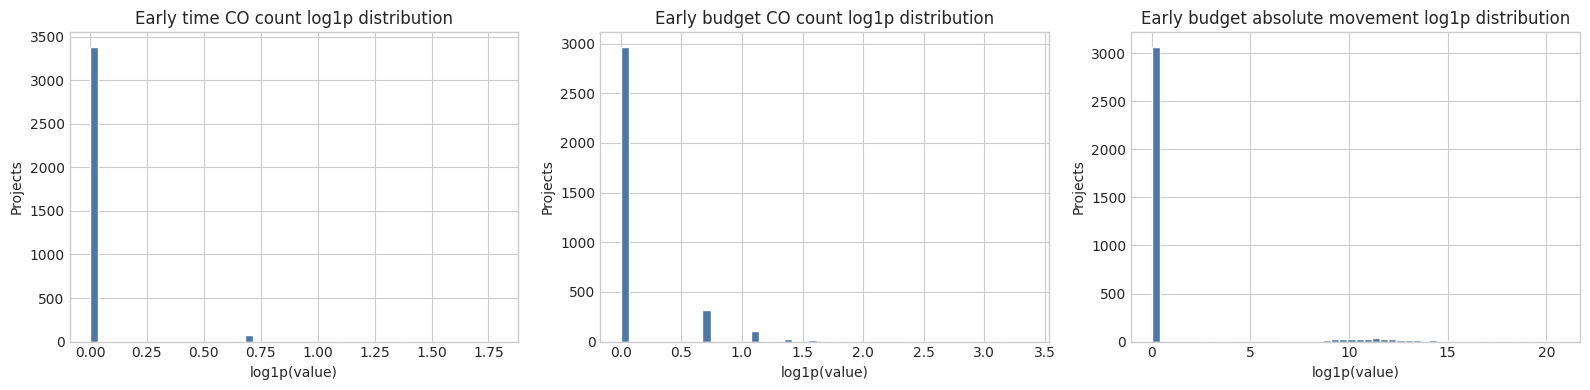

,Feature,NonZeroProjects,NonZeroShare,Median,P95,Max
8,TIMECO_EARLY_COUNT_PRESTART,4,0.1%,0,0,1
23,BUDGETCO_EARLY_LINE_COUNT_PRESTART,26,0.7%,0,0,37
9,TIMECO_EARLY_COUNT_PCT_0_25,34,1.0%,0,0,5
10,TIMECO_EARLY_COUNT_PCT_25_50,56,1.6%,0,0,2
4,TIMECO_EARLY_MEDIAN_ADDED_DAYS,89,2.6%,0,0,422
3,TIMECO_EARLY_MEAN_ADDED_DAYS,89,2.6%,0,0,422
1,TIMECO_EARLY_DISTINCT_CO_COUNT,89,2.6%,0,0,5
2,TIMECO_EARLY_TOTAL_ADDED_DAYS,89,2.6%,0,0,422
0,TIMECO_EARLY_ROW_COUNT,89,2.6%,0,0,5
6,TIMECO_EARLY_FIRST_APPROVED_PCT,89,2.6%,0,0,49.5


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title in [
    (axes[0], 'TIMECO_EARLY_DISTINCT_CO_COUNT', 'Early time CO count'),
    (axes[1], 'BUDGETCO_EARLY_DISTINCT_CO_COUNT', 'Early budget CO count'),
    (axes[2], 'BUDGETCO_EARLY_ABS_DELTA', 'Early budget absolute movement'),
]:
    if col in df.columns:
        s = pd.to_numeric(df[col], errors='coerce').fillna(0)
        ax.hist(np.log1p(s.clip(lower=0)), bins=50, color='#4c78a8', edgecolor='white')
        ax.set_title(title + ' log1p distribution')
        ax.set_xlabel('log1p(value)')
        ax.set_ylabel('Projects')
plt.tight_layout()
plt.show()

sparsity = []
for c in co_cols:
    s = pd.to_numeric(df[c], errors='coerce').fillna(0)
    sparsity.append({'Feature': c, 'NonZeroProjects': int((s != 0).sum()), 'NonZeroShare': (s != 0).mean(), 'Median': s.median(), 'P95': s.quantile(.95), 'Max': s.max()})
sparsity_df = pd.DataFrame(sparsity).sort_values('NonZeroShare')
display(sparsity_df.style.format({'NonZeroShare': '{:.1%}', 'Median': '{:,.3g}', 'P95': '{:,.3g}', 'Max': '{:,.3g}'}))

## Hypothesis 2: CO Presence Changes The Population Mix

This checks whether projects with early COs have a different final delay distribution. If they are concentrated in one or two classes, they may shift calibration but still not help distinguish all three classes.


Target distribution by HasEarlyTimeCO


DelayBinLabel,before/on time,mildly late,moderate/severe late
HasEarlyTimeCO,,,
False,48.5%,3.3%,48.2%
True,20.2%,11.2%,68.5%


DelayBinLabel,before/on time,mildly late,moderate/severe late
HasEarlyTimeCO,,,
False,1640,110,1630
True,18,10,61



Target distribution by HasEarlyBudgetCO


DelayBinLabel,before/on time,mildly late,moderate/severe late
HasEarlyBudgetCO,,,
False,49.8%,3.0%,47.2%
True,35.8%,6.2%,58.1%


DelayBinLabel,before/on time,mildly late,moderate/severe late
HasEarlyBudgetCO,,,
False,1478,89,1399
True,180,31,292



Target distribution by HasAnyEarlyCO


DelayBinLabel,before/on time,mildly late,moderate/severe late
HasAnyEarlyCO,,,
False,49.9%,3.0%,47.1%
True,35.6%,6.1%,58.3%


DelayBinLabel,before/on time,mildly late,moderate/severe late
HasAnyEarlyCO,,,
False,1476,89,1393
True,182,31,298


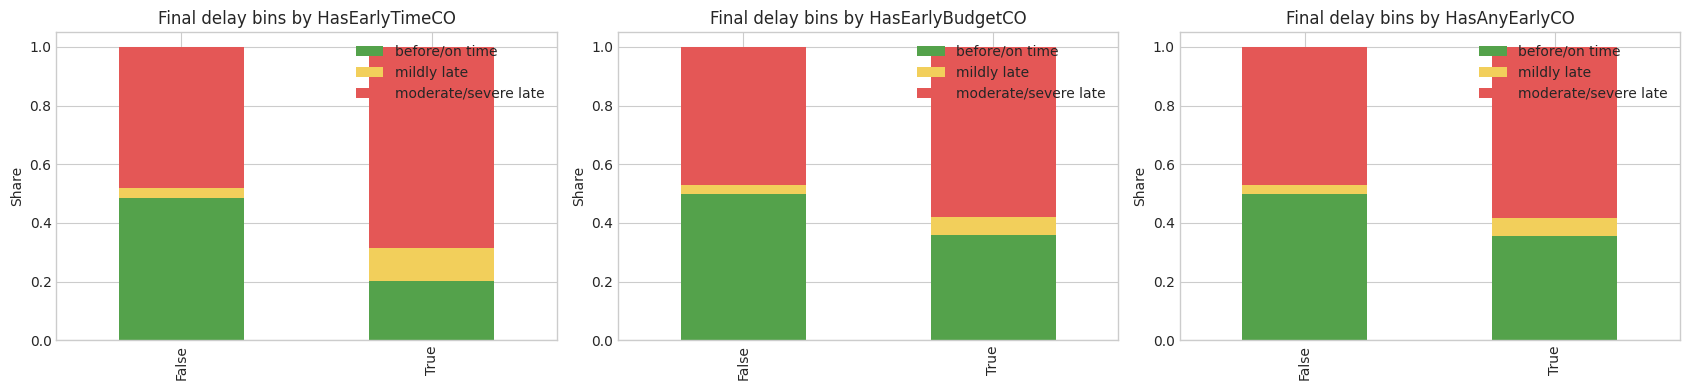

In [5]:
for flag in ['HasEarlyTimeCO', 'HasEarlyBudgetCO', 'HasAnyEarlyCO']:
    print(f'\nTarget distribution by {flag}')
    tab = pd.crosstab(df[flag], df['DelayBinLabel'], normalize='index')
    counts = pd.crosstab(df[flag], df['DelayBinLabel'])
    display(tab.style.format('{:.1%}'))
    display(counts)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, flag in zip(axes, ['HasEarlyTimeCO', 'HasEarlyBudgetCO', 'HasAnyEarlyCO']):
    tab = pd.crosstab(df[flag], df['DelayBinLabel'], normalize='index')
    tab = tab.reindex(columns=['before/on time','mildly late','moderate/severe late'])
    tab.plot(kind='bar', stacked=True, ax=ax, color=['#54a24b','#f2cf5b','#e45756'])
    ax.set_title(f'Final delay bins by {flag}')
    ax.set_xlabel('')
    ax.set_ylabel('Share')
    ax.legend(loc='best')
plt.tight_layout()
plt.show()

## Hypothesis 3: Early CO Signal Drifts Between Train And Test

If early CO coverage, amounts, or target relationships differ between older and newer projects, time-split performance can degrade even if cross-validation looked promising.

In [6]:
def stable_hash_fraction(*parts):
    key = '||'.join('' if pd.isna(p) else str(p) for p in parts)
    digest = hashlib.md5(key.encode('utf-8')).hexdigest()
    return int(digest[:12], 16) / float(16**12)

df['HashFrac'] = [stable_hash_fraction(c, p) for c,p in zip(df['CUSTOMERNAME'], df['PROJECTID'])]
df['HashSplit'] = np.where(df['HashFrac'] < .8, 'hash_train', 'hash_test')
time_cutoff = df['PLANNEDSTARTDATE'].quantile(.80)
df['TimeSplit'] = np.where(df['PLANNEDSTARTDATE'] <= time_cutoff, 'time_train_old80', 'time_test_new20')

split_rows = []
for split_col in ['HashSplit', 'TimeSplit']:
    for split_value, g in df.groupby(split_col):
        split_rows.append({
            'SplitType': split_col,
            'Split': split_value,
            'Rows': len(g),
            'HasEarlyTimeCO': g['HasEarlyTimeCO'].mean(),
            'HasEarlyBudgetCO': g['HasEarlyBudgetCO'].mean(),
            'HasAnyEarlyCO': g['HasAnyEarlyCO'].mean(),
            'MeanTimeAddedDays': g.get('TIMECO_EARLY_TOTAL_ADDED_DAYS', pd.Series(0, index=g.index)).mean(),
            'MeanBudgetAbsDelta': g.get('BUDGETCO_EARLY_ABS_DELTA', pd.Series(0, index=g.index)).mean(),
            'ModerateSevereLateShare': (g['DelayBin'] == 2).mean(),
            'MildLateShare': (g['DelayBin'] == 1).mean(),
            'OnTimeShare': (g['DelayBin'] == 0).mean(),
        })
split_profile = pd.DataFrame(split_rows)
display(split_profile.style.format({
    'HasEarlyTimeCO': '{:.1%}', 'HasEarlyBudgetCO': '{:.1%}', 'HasAnyEarlyCO': '{:.1%}',
    'ModerateSevereLateShare': '{:.1%}', 'MildLateShare': '{:.1%}', 'OnTimeShare': '{:.1%}',
    'MeanTimeAddedDays': '{:,.2f}', 'MeanBudgetAbsDelta': '${:,.0f}'
}))

,SplitType,Split,Rows,HasEarlyTimeCO,HasEarlyBudgetCO,HasAnyEarlyCO,MeanTimeAddedDays,MeanBudgetAbsDelta,ModerateSevereLateShare,MildLateShare,OnTimeShare
0,HashSplit,hash_test,726,2.1%,13.8%,14.0%,1.94,"$849,910",47.9%,2.6%,49.4%
1,HashSplit,hash_train,2743,2.7%,14.7%,14.9%,0.81,"$1,439,312",49.0%,3.7%,47.4%
2,TimeSplit,time_test_new20,693,4.3%,20.3%,20.9%,2.46,"$1,180,350",50.6%,5.9%,43.4%
3,TimeSplit,time_train_old80,2776,2.1%,13.0%,13.2%,0.70,"$1,349,815",48.3%,2.8%,48.9%


## Hypothesis 4: CO Features Have Weak Standalone Predictive Power

This section fits simple regularized random forests using only early CO features. If these models are weak, then adding CO features to a strong baseline can add noise more easily than signal.

In [7]:
y = df['DelayBin'].astype(int)
co_feature_sets = {
    'time_co_only': time_cols,
    'budget_co_only': budget_cols,
    'all_co_only': co_cols,
}
co_only_rows = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, cols in co_feature_sets.items():
    if not cols:
        continue
    X = df[cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            class_weight='balanced_subsample',
            min_samples_leaf=20,
            min_samples_split=10,
            max_features='sqrt',
            n_jobs=-1,
        ))
    ])
    scores = cross_val_score(model, X, y, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
    co_only_rows.append({'FeatureSet': name, 'MeanCVBalancedAccuracy': scores.mean(), 'StdCVBalancedAccuracy': scores.std(), 'FeatureCount': len(cols)})
co_only = pd.DataFrame(co_only_rows)
display(co_only.style.format({'MeanCVBalancedAccuracy': '{:.3f}', 'StdCVBalancedAccuracy': '{:.3f}'}))

,FeatureSet,MeanCVBalancedAccuracy,StdCVBalancedAccuracy,FeatureCount
0,time_co_only,0.358,0.009,11
1,budget_co_only,0.392,0.010,19
2,all_co_only,0.397,0.011,30


## Hypothesis 5: Regularized Forests Prefer Baseline Features

The combined-model feature importance files show how much the final model relied on CO features. If few CO features appear near the top, they are not adding much global splitting power.


hash_80_20: top feature type summary


,FeatureType,Top40Count,TotalImportance
0,Baseline setup feature,40,0.524756


,Feature,Importance,FeatureType
0,DOLLARSPERPLANNEDDAY,0.029222,Baseline setup feature
1,PROJECTPLANNEDVALUE,0.024677,Baseline setup feature
2,MAXITEMPLANNEDVALUE,0.022871,Baseline setup feature
3,DOLLARSPERCONTRACT,0.021507,Baseline setup feature
4,MEANITEMPLANNEDVALUE,0.020626,Baseline setup feature
5,ABSPROJECTPLANNEDVALUE,0.019432,Baseline setup feature
6,MEDIANITEMPLANNEDVALUE,0.018347,Baseline setup feature
7,UNITPRICEP90,0.018254,Baseline setup feature
8,MAXCONTRACTPLANNEDDURATIONDAYS,0.017882,Baseline setup feature
9,UNITPRICEMAX,0.017686,Baseline setup feature


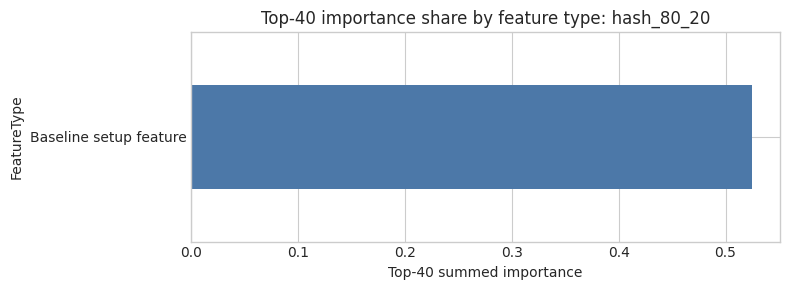


time_old_80_new_20: top feature type summary


,FeatureType,Top40Count,TotalImportance
0,Baseline setup feature,40,0.515842


,Feature,Importance,FeatureType
0,UNITPRICEP90,0.024133,Baseline setup feature
1,PROJECTPLANNEDVALUE,0.023421,Baseline setup feature
2,DOLLARSPERPLANNEDDAY,0.022440,Baseline setup feature
3,DOLLARSPERPLANNEDMONTH,0.020971,Baseline setup feature
4,MEANITEMPLANNEDVALUE,0.020701,Baseline setup feature
5,LOG1PABSPROJECTPLANNEDVALUE,0.018992,Baseline setup feature
6,STDDEVITEMPLANNEDVALUE,0.018252,Baseline setup feature
7,ITEM_KW_MOBILIZATION_ITEM_SHARE,0.018092,Baseline setup feature
8,MEDIANCONTRACTPLANNEDDURATIONDAYS,0.017257,Baseline setup feature
9,MAXCONTRACTPLANNEDDURATIONDAYS,0.017081,Baseline setup feature


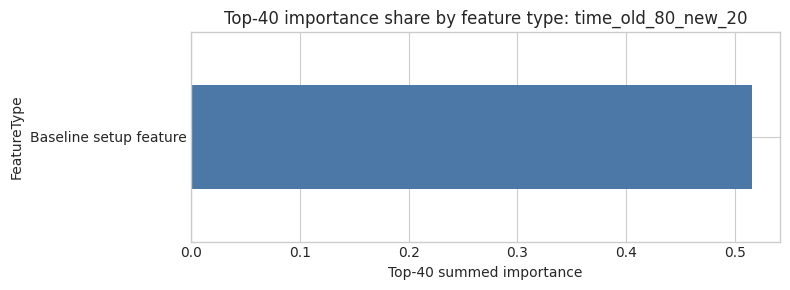

In [8]:
for name, imp in [('hash_80_20', hash_imp), ('time_old_80_new_20', time_imp)]:
    imp = imp.copy()
    imp['FeatureType'] = np.select(
        [imp['Feature'].str.startswith('TIMECO_'), imp['Feature'].str.startswith('BUDGETCO_')],
        ['Early time CO', 'Early budget CO'],
        default='Baseline setup feature'
    )
    print(f'\n{name}: top feature type summary')
    display(imp.groupby('FeatureType').agg(Top40Count=('Feature','size'), TotalImportance=('Importance','sum')).reset_index().sort_values('TotalImportance', ascending=False))
    display(imp.head(25))
    ax = imp.groupby('FeatureType')['Importance'].sum().sort_values().plot(kind='barh', figsize=(8,3), color='#4c78a8')
    ax.set_title(f'Top-40 importance share by feature type: {name}')
    ax.set_xlabel('Top-40 summed importance')
    plt.tight_layout()
    plt.show()

## Hypothesis 6: Incremental CO Features May Improve Only A Subset

Even if global performance drops, CO features may help on projects that actually have early COs. This section compares model results on the subset of test projects with any early CO.

In [9]:
# Recreate the exact feature sets from available columns in the audit table.
# Baseline columns are not in the audit table, so this subset diagnostic uses result interpretation plus CO-only separability.
subset_rows = []
for split_col, split_test in [('HashSplit', 'hash_test'), ('TimeSplit', 'time_test_new20')]:
    g = df[df[split_col] == split_test]
    for flag in ['HasEarlyTimeCO', 'HasEarlyBudgetCO', 'HasAnyEarlyCO']:
        sub = g[g[flag]]
        subset_rows.append({
            'SplitType': split_col,
            'TestSplit': split_test,
            'Subset': flag,
            'Rows': len(sub),
            'ShareOfTest': len(sub) / max(len(g), 1),
            'OnTimeShare': (sub['DelayBin'] == 0).mean() if len(sub) else np.nan,
            'MildLateShare': (sub['DelayBin'] == 1).mean() if len(sub) else np.nan,
            'ModerateSevereLateShare': (sub['DelayBin'] == 2).mean() if len(sub) else np.nan,
        })
subset_df = pd.DataFrame(subset_rows)
display(subset_df.style.format({'ShareOfTest': '{:.1%}', 'OnTimeShare': '{:.1%}', 'MildLateShare': '{:.1%}', 'ModerateSevereLateShare': '{:.1%}'}))

,SplitType,TestSplit,Subset,Rows,ShareOfTest,OnTimeShare,MildLateShare,ModerateSevereLateShare
0,HashSplit,hash_test,HasEarlyTimeCO,15,2.1%,13.3%,13.3%,73.3%
1,HashSplit,hash_test,HasEarlyBudgetCO,100,13.8%,36.0%,8.0%,56.0%
2,HashSplit,hash_test,HasAnyEarlyCO,102,14.0%,35.3%,7.8%,56.9%
3,TimeSplit,time_test_new20,HasEarlyTimeCO,30,4.3%,36.7%,26.7%,36.7%
4,TimeSplit,time_test_new20,HasEarlyBudgetCO,141,20.3%,39.0%,12.8%,48.2%
5,TimeSplit,time_test_new20,HasAnyEarlyCO,145,20.9%,39.3%,12.4%,48.3%


## Diagnostic Takeaways And Recommended Next Steps

The diagnostics point to a straightforward explanation for the worse performance when early change-order features are added to the regularized random forest.

### Why Performance Gets Worse

1. **The CO features are sparse.** Most projects have no approved change orders by the planned midpoint. In the modeled population, only about `2.6%` of projects have early time COs and about `14%` have early budget COs. A global model trained across all projects therefore sees many zeros and only a small number of projects where CO features can matter.

2. **CO-only predictive power is weak.** The CO-only models reach only about `0.36-0.40` balanced accuracy in cross-validation. That means the CO features alone do not cleanly separate the three final delay bins.

3. **The signal is not stable over time.** The newer time-test projects have materially higher early CO coverage than the older training projects. This drift means the model learns one relationship in the training period and sees a different mix in the test period.

4. **Early COs indicate risk, but not enough class separation.** Projects with early COs are more risk-heavy than projects without them, but they still contain a mix of on-time, mildly late, and moderate/severe late outcomes. That makes them useful for context but not enough to improve a single global three-class classifier.

5. **Regularization is doing what it should.** The random forest tuning selected conservative settings. With those settings, sparse features are only useful if they repeatedly improve splits across many samples. The broader project setup features are more consistently useful than early CO features.

### What This Means

The result does not mean change orders are irrelevant. It means that, in the current form, **early approved change orders are better interpreted as conditional risk modifiers than as general-purpose features for every project.**

### Recommended Next Modeling Direction

A better structure is likely:

1. Train the baseline beginning-only project risk model.
2. Separately model the subset of projects with early approved CO activity.
3. Estimate whether CO timing, time added, and budget delta should adjust the baseline risk score up or down.
4. Consider a binary risk model first, because the three-bin severity task is harder and less stable.

This two-stage approach matches the data pattern: early COs are meaningful when present, but too sparse to improve the global model when simply appended as regular features.

In [10]:
# Export diagnostic tables.
sparsity_df.to_csv('project_delay_50pct_co_feature_sparsity_diagnostics_2026-06-14.csv', index=False)
split_profile.to_csv('project_delay_50pct_co_split_drift_diagnostics_2026-06-14.csv', index=False)
co_only.to_csv('project_delay_50pct_co_only_cv_diagnostics_2026-06-14.csv', index=False)
subset_df.to_csv('project_delay_50pct_co_subset_diagnostics_2026-06-14.csv', index=False)
print('Saved diagnostic CSVs.')

Saved diagnostic CSVs.
